##### 실행 환경 설정

In [2]:
# Google Drive를 Colab에 마운트
from google.colab import drive
drive.mount("/google_drive")

from pathlib import Path
import shutil
import zipfile
import yaml

# 작업 경로 설정
WORK_DIR = Path("/google_drive/Othercomputers/내 Mac/sec08")
if not WORK_DIR.exists():
    raise FileNotFoundError(f"작업 폴더를 찾을 수 없습니다: {WORK_DIR}")

print("\n[작업 폴더 목록]")
%cd {WORK_DIR}
!ls

# Google Drive의 ZIP을 Colab 로컬로 복사하고 압축 해제
DRIVE_DATASET_ZIP = WORK_DIR / "datasets" / "lane-seg.zip"
LOCAL_DATASET_ZIP = Path("/datasets/lane-seg.zip")
DATASET_PATH = Path("/datasets/lane-seg")

if not DRIVE_DATASET_ZIP.exists():
    raise FileNotFoundError(f"Drive에서 데이터셋 ZIP을 찾을 수 없습니다: {DRIVE_DATASET_ZIP}")

DATASET_READY = all(
    (DATASET_PATH / relative_path).exists()
    for relative_path in [
        "data.yaml", "images/train", "labels/train",
        "images/val", "labels/val", "images/test", "labels/test",
    ]
)

if not DATASET_READY:
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    LOCAL_DATASET_ZIP.parent.mkdir(parents=True, exist_ok=True)
    print("\nlane-seg.zip을 Colab 로컬로 복사 중...")
    shutil.copy2(DRIVE_DATASET_ZIP, LOCAL_DATASET_ZIP)

    print("lane-seg 데이터셋 압축 해제 중...")
    with zipfile.ZipFile(LOCAL_DATASET_ZIP, "r") as zip_file:
        zip_file.extractall(DATASET_PATH)

    LOCAL_DATASET_ZIP.unlink(missing_ok=True)

print("\n[데이터셋 폴더 목록]")
print(DATASET_PATH)
!ls {DATASET_PATH}
!ls {DATASET_PATH}/images
!ls {DATASET_PATH}/labels

# data.yaml의 path를 Colab 절대 경로로 변경
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, "r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

cfg["path"] = str(DATASET_PATH)

with open(yaml_path, "w", encoding="utf-8") as file:
    yaml.safe_dump(cfg, file, allow_unicode=True, sort_keys=False)

# 비디오 실습 파일은 Drive에서 Colab 로컬로 복사
DRIVE_VIDEO_CANDIDATES = [
    WORK_DIR / "datasets" / "videos" / "lane-seg.mp4",
    WORK_DIR.parent / "datasets" / "videos" / "lane-seg.mp4",
]
DRIVE_VIDEO_PATH = next(
    (path for path in DRIVE_VIDEO_CANDIDATES if path.exists()),
    DRIVE_VIDEO_CANDIDATES[0],
)
VIDEO_PATH = Path("/datasets/videos/lane-seg.mp4")
if DRIVE_VIDEO_PATH.exists() and not VIDEO_PATH.exists():
    VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(DRIVE_VIDEO_PATH, VIDEO_PATH)
    print(f"비디오 복사 완료: {DRIVE_VIDEO_PATH} -> {VIDEO_PATH}")
elif not DRIVE_VIDEO_PATH.exists():
    print("비디오 원본을 찾지 못했습니다. 마지막 비디오 셀만 실행할 수 없습니다.")
    for candidate in DRIVE_VIDEO_CANDIDATES:
        print(f"  - {candidate}")

# 한글 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

lane-seg.zip을 Colab 로컬로 복사 중...
lane-seg 데이터셋 압축 해제 중...

[데이터셋 폴더 목록]
/datasets/lane-seg
data.yaml  images  labels
test  train  val
test  train  val
비디오 복사 완료: /google_drive/Othercomputers/내 Mac/sec08/datasets/videos/lane-seg.mp4 -> /datasets/videos/lane-seg.mp4
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers 

##### 임포트

In [3]:
%pip install -q -U ultralytics

from ultralytics import YOLO
import torch
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.image as mpimg
import cv2
import glob
import random
import numpy as np
import time

# 노트북 셀에서 이미지 출력하기 위한 라이브러리(노트북에서 이미지 렌더링 속도 향상을 위해 사용)
from IPython.display import clear_output, Image as IPImage, display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##### Device 설정

In [4]:
# GPU가 있으면 첫 번째 CUDA GPU를 사용하고, 없으면 CPU 사용
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", "cuda:0" if DEVICE == 0 else DEVICE)
if DEVICE == 0:
    print("GPU 이름:", torch.cuda.get_device_name(0))

사용 디바이스: cuda:0
GPU 이름: Tesla T4


##### 모델 로드

In [5]:
# 06번에서 학습한 최적 가중치(best.pt) 로드
BEST_MODEL_PATH = Path(WORK_DIR) / "runs" / "segment" / "06" / "weights" / "best.pt"
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"학습된 모델이 없습니다. 06번을 먼저 실행하세요: {BEST_MODEL_PATH}")

best_model = YOLO(str(BEST_MODEL_PATH))

##### 추론하기

In [6]:
# 테스트셋 이미지 목록에서 랜덤으로 한 장 선택
test_images = sorted((DATASET_PATH / "images" / "test").glob("*.jpg"))
if not test_images:
    raise FileNotFoundError(f"테스트 이미지를 찾을 수 없습니다: {DATASET_PATH / 'images' / 'test'}")

test_image = random.choice(test_images)
print(f"선택된 이미지: {test_image}")

# 추론 결과를 Google Drive에 저장
PREDICT_PROJECT = Path(WORK_DIR) / "runs" / "segment" / "07"
pred_results = best_model.predict(
    str(test_image),
    # conf=0.25,                    # 신뢰도 임계값
    device=DEVICE,
    save=True,
    project=str(PREDICT_PROJECT),
    name="predict",
    exist_ok=True,
    verbose=False,
)

선택된 이미지: /datasets/lane-seg/images/test/lane_train_009.jpg
Results saved to /google_drive/Othercomputers/내 Mac/sec08/runs/segment/07/predict


##### 추론 시각화: 방법1 - Ultralytics 내장 시각화

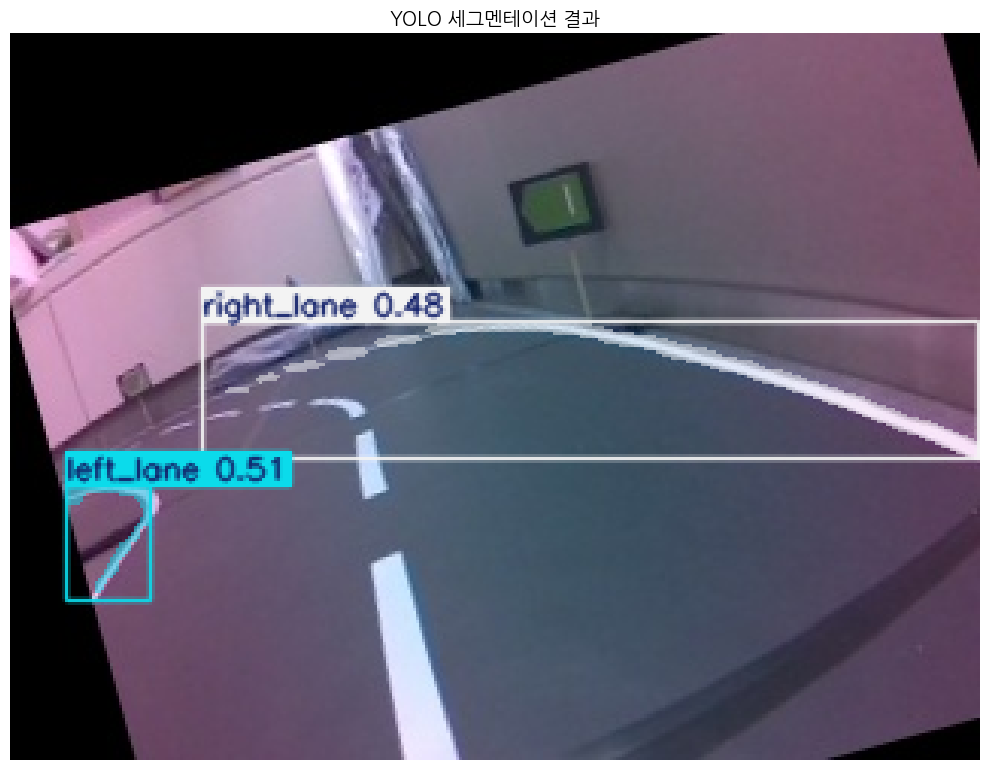

In [7]:
# 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
annotated_bgr = pred_results[0].plot(
    line_width=1,    # 바운딩 박스 선 두께
    font_size=5,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
    conf=True,       # 신뢰도 표시 여부
    labels=True,     # 레이블 표시 여부
)
# BGR 이미지를 RGB로 변환 (OpenCV는 BGR, Matplotlib는 RGB)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# Matplotlib으로 결과 이미지 표시
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(annotated_rgb)
ax.axis("off")
ax.set_title("YOLO 세그멘테이션 결과", fontsize=14)
plt.tight_layout()
plt.show()

##### 추론 시각화: 방법2 - matplotlib으로 마스크 직접 그리기

선택된 이미지: /datasets/lane-seg/images/test/lane_train_009.jpg
Results saved to /google_drive/Othercomputers/내 Mac/sec08/runs/segment/07/predict


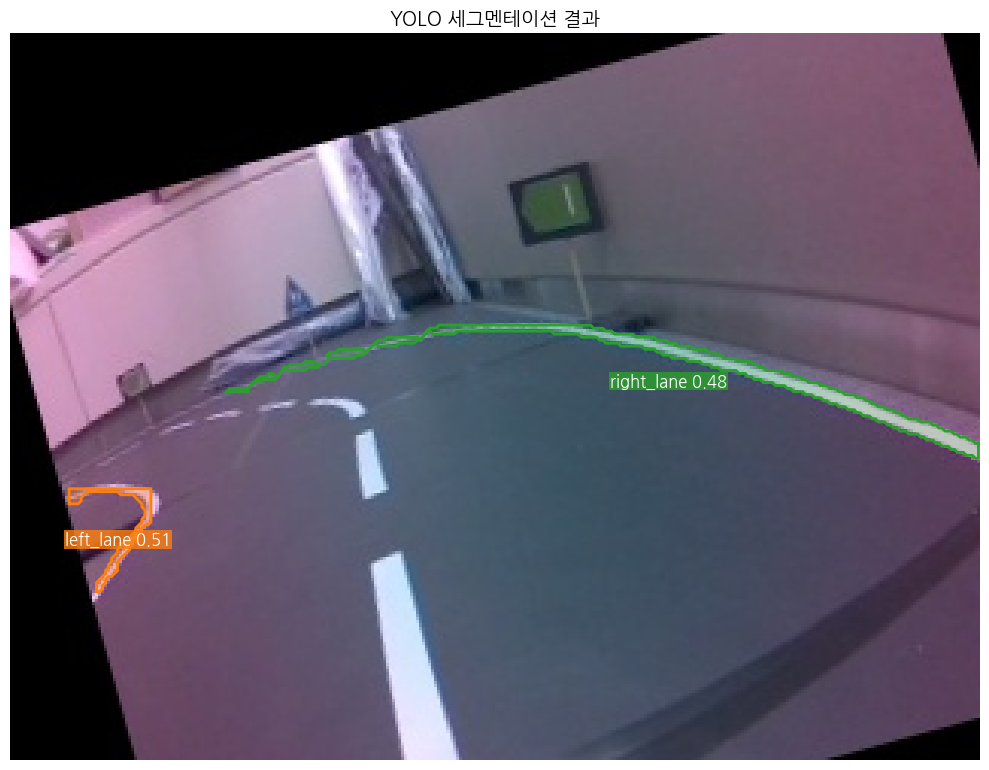

In [8]:
# 테스트셋 이미지 목록에서 랜덤으로 한 장 선택
test_images = sorted((DATASET_PATH / "images" / "test").glob("*.jpg"))
if not test_images:
    raise FileNotFoundError(f"테스트 이미지를 찾을 수 없습니다: {DATASET_PATH / 'images' / 'test'}")

test_image = random.choice(test_images)
print(f"선택된 이미지: {test_image}")

# 추론
pred_results = best_model.predict(
    str(test_image),
    # conf=0.25,                    # 신뢰도 임계값
    device=DEVICE,
    save=True,
    project=str(PREDICT_PROJECT),
    name="predict",
    exist_ok=True,
    verbose=False,
)

# 원본 이미지 로드
img = mpimg.imread(test_image)

# matplotlib으로 마스크 직접 그리기
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("YOLO 세그멘테이션 결과", fontsize=14)

# 탐지된 객체의 바운딩 박스 정보 추출
boxes = pred_results[0].boxes
# 탐지된 객체의 세그멘테이션 마스크 정보 추출
masks = pred_results[0].masks

# 클래스별 고유 색상 생성
# tab10 컬러 맵: 범주형 데이터에 최적화된 10가지 뚜렷한 색상 제공
cmap = plt.colormaps.get_cmap("tab10")

# 폴리곤 마스크와 레이블 그리기
if masks is not None:
    # 탐지된 객체 수만큼 반복하여 폴리곤 마스크와 레이블 그리기
    for poly, box in zip(masks.xy, boxes):
        # 클래스 레이블 얻기
        class_id = int(box.cls.item())
        # 클래스 이름 추출
        class_name = best_model.names[class_id]
        # 신뢰도 추출
        confidence = float(box.conf.item())
        # 클래스 레이블로 색상 선택
        color = cmap(class_id)

        # 폴리곤 마스크 그리기
        polygon = patches.Polygon(
            poly, closed=True,
            # 폴리곤 내부를 반투명하게 채우기
            # *color[:3]: RGBA 튜플에서 RGB 값만 추출
            # 0.3: 투명도 (alpha) 값으로 폴리곤 내부를 반투명하게 채우기
            facecolor=(*color[:3], 0.3),
            # 폴리곤 외곽선 색상 설정
            edgecolor=color,
            # 폴리곤 외곽선 두께 설정
            linewidth=2
        )
        # 폴리곤을 그래프에 추가
        ax.add_patch(polygon)

        # 레이블 텍스트 그리기 (폴리곤의 중앙에 위치)
        # poly는 (N, 2) 형태의 numpy 배열로, 각 행이 (x, y) 좌표를 나타냄
        # 모든 x 좌표의 평균 → 폴리곤 중심 x
        cx = poly[:, 0].mean()
        # 모든 y 좌표의 평균 → 폴리곤 중심 y
        cy = poly[:, 1].mean()

        # 클래스 이름과 신뢰도 레이블을 폴리곤의 중앙에 표시
        ax.text(
            cx, cy,  # 폴리곤 중심에 레이블 위치
            f"{class_name} {confidence:.2f}",  # 클래스 이름과 신뢰도 표시
            fontsize=12, color="white",  # 글자 크기와 색상
            ha="center", va="center",    # 가로/세로 중앙 정렬
            bbox={
                "facecolor":color, # 레이블 배경 색상 (바운딩 박스와 동일)
                "alpha":0.8, # 레이블 배경 투명도
                "pad":1,  # 레이블 배경과 글자 사이의 패딩
                "edgecolor":"none" # 레이블 배경 테두리 없음
            }
        )

plt.tight_layout()
plt.show()


업로드된 이미지를 추론해서 다운로드시키기

저장 완료: /google_drive/Othercomputers/내 Mac/sec08/runs/segment/07/predict/lane_train_009.jpg


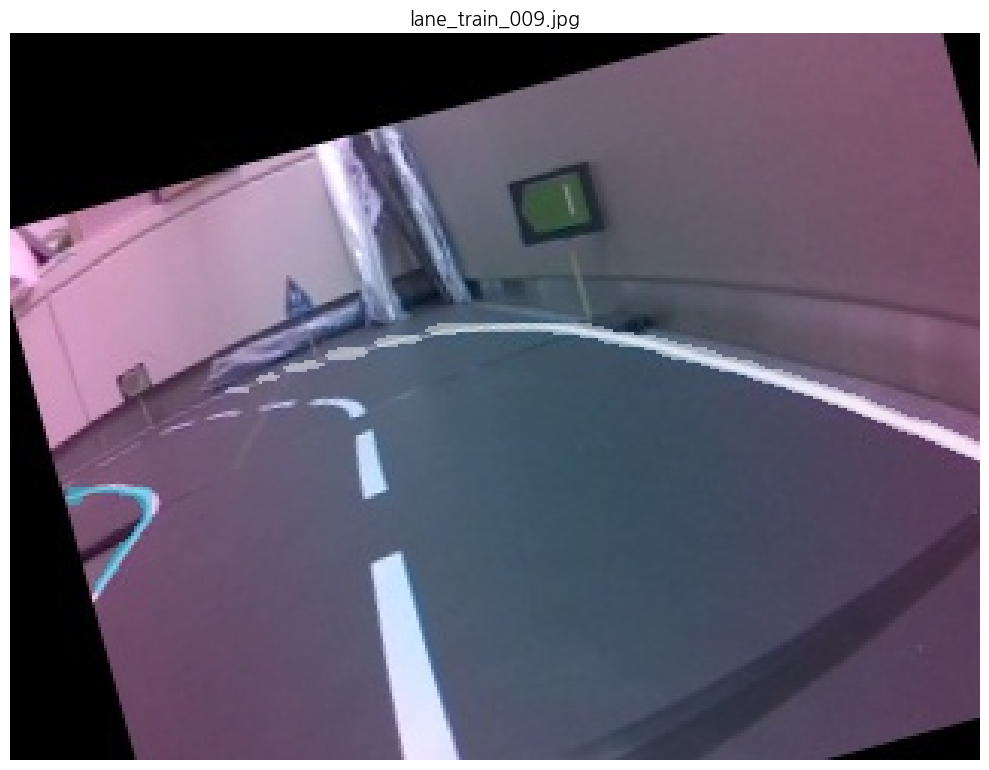

In [9]:
# 업로드된 이미지라고 가정
INPUT_PATH = DATASET_PATH / "images" / "test" / "lane_train_009.jpg"
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"입력 이미지가 없습니다: {INPUT_PATH}")

# 추론 결과를 저장할 경로
OUTPUT_PATH = PREDICT_PROJECT / "predict" / INPUT_PATH.name

# 업로드된 파일의 바이트 배열 읽기
image_bytes = INPUT_PATH.read_bytes()

# 바이트 배열을 numpy ndarray로 변환
nparr = np.frombuffer(image_bytes, np.uint8)

# OpenCV로 디코딩하여 BGR 순서의 이미지 얻기
img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

# 추론
result = best_model.predict(img_bgr, device=DEVICE, verbose=False)

# result[0].plot(): 추론 결과가 그려진 이미지 반환 (BGR 순서의 numpy ndarray)
# cv.imencode(): JPEG 형식으로 인코딩
# success: 인코딩 성공 여부
# jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
success, jpg_img = cv2.imencode(".jpg", result[0].plot(boxes=False))  # 바운딩 박스 제거
result_bytes = jpg_img.tobytes()

# 추론 결과를 파일로 다운로드
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_bytes(result_bytes)
print(f"저장 완료: {OUTPUT_PATH.resolve()}")

# 추론 결과 이미지 보기
img = mpimg.imread(str(OUTPUT_PATH))
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("lane_train_009.jpg", fontsize=14)
plt.tight_layout()
plt.show()

실시간 비디오 영상 추론하고 시각화하기

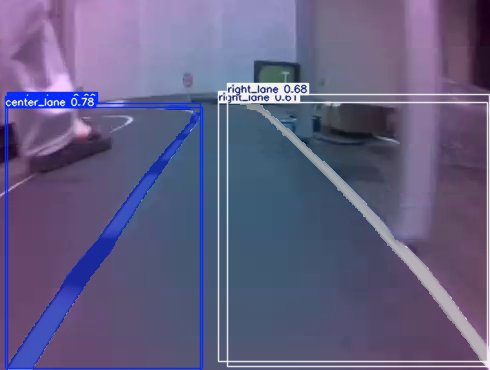

In [10]:
# 실제로는 스트리밍으로 입력으로 프레임 얻기
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"비디오 파일이 없습니다: {VIDEO_PATH} (Drive 원본: {DRIVE_VIDEO_PATH})"
    )

frame = cv2.VideoCapture(str(VIDEO_PATH))

# 프레임 속도(FPS) 계산
fps = frame.get(cv2.CAP_PROP_FPS) or 30
print(f"FPS: {fps:.2f}")
frame_interval = 1 / fps

try:
    # 프레임 단위로 영상 처리
    while frame.isOpened():
        # 시작 시간 기록
        t0 = time.time()
        # 프레임 읽기
        # success: 프레임 읽기 성공 여부, frame_bgr: 읽은 프레임 (BGR 순서의 numpy ndarray)
        success, frame_bgr = frame.read()
        if not success:
            break

        # 추론 → JPEG bytes
        pred_results = best_model.predict(frame_bgr, device=DEVICE, verbose=False)

        # 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
        annotated_bgr = pred_results[0].plot(
            line_width=1,    # 바운딩 박스 선 두께
            font_size=5,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
            conf=True,       # 신뢰도 표시 여부
            labels=True,     # 레이블 표시 여부
        )
        # success: 인코딩 성공 여부, jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
        success, jpg_img = cv2.imencode(".jpg", annotated_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])

        # JPEG -> 바이트 배열로 변환
        jpg_bytes  = jpg_img.tobytes()

        # 이전 프레임 지우고 노트북에 프레임 보여주기
        # wait=False: 즉시 출력 지움. 다음 프레임이 나타날 때까지 빈 화면이 잠깐 보임 (깜빡임 발생)
        # wait=True: 이전 프레임이 사라지지 않고 다음 프레임이 나타날 때까지 유지 (깜빡임 없음)
        clear_output(wait=True)
        display(IPImage(data=jpg_bytes, width=800))

        # 추론·표시에 걸린 시간만큼 sleep 차감
        elapsed = time.time() - t0
        wait = frame_interval - elapsed
        if wait > 0:
            time.sleep(wait)
finally:
    # 프레임 자원 해제
    frame.release()
